In [50]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import multivariate_normal as mvn

In [ ]:
data = pd.read_csv('Cirrhosis.csv')
data


,index,duration,status,drug,age,sex,ascites,hepatomology,spiders,edema,bilirubin,cholesterol,albumin,copper,phosphatase,SGOT,triglicerides,platelets,prothrombin,stage
0,1,400,2,1,21464,1,1,1,1,1.0,14.5,261.0,2.60,156.0,1718.0,137.95,172.0,190.0,12.2,4
1,2,4500,0,1,20617,1,0,1,1,0.0,1.1,302.0,4.14,54.0,7394.8,113.52,88.0,221.0,10.6,3
2,3,1012,2,1,25594,0,0,0,0,0.5,1.4,176.0,3.48,210.0,516.0,96.10,55.0,151.0,12.0,4
3,4,1925,2,1,19994,1,0,1,1,0.5,1.8,244.0,2.54,64.0,6121.8,60.63,92.0,183.0,10.3,4
4,5,1504,1,2,13918,1,0,1,1,0.0,3.4,279.0,3.53,143.0,671.0,113.15,72.0,136.0,10.9,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
307,308,1153,0,1,22347,1,0,1,0,0.0,0.4,246.0,3.58,24.0,797.0,91.00,113.0,288.0,10.4,2
308,309,994,0,2,21294,1,0,0,0,0.0,0.4,260.0,2.75,41.0,1166.0,70.00,82.0,231.0,10.8,2
309,310,939,0,1,22767,1,0,0,0,0.0,1.7,434.0,3.35,39.0,1713.0,171.00,100.0,234.0,10.2,2
310,311,839,0,1,13879,1,0,0,0,0.0,2.0,247.0,3.16,69.0,1050.0,117.00,88.0,335.0,10.5,2


In [4]:
data.describe()

,index,duration,status,drug,age,sex,ascites,hepatomology,spiders,edema,bilirubin,cholesterol,albumin,copper,phosphatase,SGOT,triglicerides,platelets,prothrombin,stage
count,312.000000,312.000000,312.000000,312.000000,312.000000,312.000000,312.000000,312.000000,312.000000,312.000000,312.000000,284.000000,312.000000,310.000000,312.000000,312.000000,282.000000,308.000000,312.000000,312.000000
mean,156.500000,2006.362179,0.862179,1.493590,18269.442308,0.884615,0.076923,0.512821,0.288462,0.110577,3.256090,369.510563,3.520000,97.648387,1982.655769,122.556346,124.702128,261.935065,10.725641,3.032051
std,90.210864,1123.280843,0.960764,0.500762,3864.805407,0.319999,0.266897,0.500639,0.453775,0.274507,4.530315,231.944545,0.419892,85.613920,2140.388824,56.699525,65.148639,95.608742,1.004323,0.877880
min,1.000000,41.000000,0.000000,1.000000,9598.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.300000,120.000000,1.960000,4.000000,289.000000,26.350000,33.000000,62.000000,9.000000,1.000000
25%,78.750000,1191.000000,0.000000,1.000000,15427.750000,1.000000,0.000000,0.000000,0.000000,0.000000,0.800000,249.500000,3.310000,41.250000,871.500000,80.600000,84.250000,199.750000,10.000000,2.000000
50%,156.500000,1839.500000,0.000000,1.000000,18187.500000,1.000000,0.000000,1.000000,0.000000,0.000000,1.350000,309.500000,3.550000,73.000000,1259.000000,114.700000,108.000000,257.000000,10.600000,3.000000
75%,234.250000,2697.250000,2.000000,2.000000,20715.000000,1.000000,0.000000,1.000000,1.000000,0.000000,3.425000,400.000000,3.800000,123.000000,1980.000000,151.900000,151.000000,322.500000,11.100000,4.000000
max,312.000000,4556.000000,2.000000,2.000000,28650.000000,1.000000,1.000000,1.000000,1.000000,1.000000,28.000000,1775.000000,4.640000,588.000000,13862.400000,457.250000,598.000000,563.000000,17.100000,4.000000


In [5]:
data.fillna(np.mean(data,axis=0), inplace=True)
data.info()
# np.mean(data,axis=0)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 312 entries, 0 to 311
Data columns (total 20 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   index          312 non-null    int64  
 1   duration       312 non-null    int64  
 2   status         312 non-null    int64  
 3   drug           312 non-null    int64  
 4   age            312 non-null    int64  
 5   sex            312 non-null    int64  
 6   ascites        312 non-null    int64  
 7   hepatomology   312 non-null    int64  
 8   spiders        312 non-null    int64  
 9   edema          312 non-null    float64
 10  bilirubin      312 non-null    float64
 11  cholesterol    312 non-null    float64
 12  albumin        312 non-null    float64
 13  copper         312 non-null    float64
 14  phosphatase    312 non-null    float64
 15  SGOT           312 non-null    float64
 16  triglicerides  312 non-null    float64
 17  platelets      312 non-null    float64
 18  prothrombi

In [6]:
data.corr()['stage']


index           -0.050346
duration        -0.371641
status           0.344549
drug             0.066298
age              0.168182
sex             -0.021131
ascites          0.250187
hepatomology     0.467293
spiders          0.291512
edema            0.252104
bilirubin        0.241367
cholesterol      0.010395
albumin         -0.336970
copper           0.268273
phosphatase      0.041273
SGOT             0.164945
triglicerides    0.115358
platelets       -0.247550
prothrombin      0.260917
stage            1.000000
Name: stage, dtype: float64

In [7]:
a = np.arange(25).reshape(5,5)
print(a)
b = (a-np.min(a,axis=0))/(a.max(axis=0)-a.min(axis=0))
print(b)

[[ 0  1  2  3  4]
 [ 5  6  7  8  9]
 [10 11 12 13 14]
 [15 16 17 18 19]
 [20 21 22 23 24]]
[[0.   0.   0.   0.   0.  ]
 [0.25 0.25 0.25 0.25 0.25]
 [0.5  0.5  0.5  0.5  0.5 ]
 [0.75 0.75 0.75 0.75 0.75]
 [1.   1.   1.   1.   1.  ]]


In [21]:
data_np = data.to_numpy()
data_np_scaled = (data_np-data_np.min(axis=0))/(data_np.max(axis=0)-data_np.min(axis=0))
X = data_np_scaled[:,0:-1]
y = data_np[:,-1].astype(int) - 1
print(X.shape,y.shape)

(312, 19) (312,)


In [22]:
def softmax(H):
    return (np.exp(H.T)/np.sum(np.exp(H),axis=1)).T 

def cat_cross_entropy(Y, P_hat):
    return -(1/len(Y))*np.sum(Y*np.log(P_hat))

def indices_to_one_hot(data, nb_classes):
    targets = np.array(data).reshape(-1)
    return np.eye(nb_classes)[targets]

def accuracy(y, y_hat):
    return np.mean(y==y_hat)

In [23]:
a = np.array([1,2,4,3])-1
b = np.ones((4,4))
b[:,a-1] = 2
np.eye(4)[a.reshape(-1)]
# sparse(5)

array([[1., 0., 0., 0.],
       [0., 1., 0., 0.],
       [0., 0., 0., 1.],
       [0., 0., 1., 0.]])

In [24]:
class MVLogisticRegression():

    def fit(self, X, y, alpha=1e-3, epochs=1e3, show_curve=True):
        epochs = int(epochs)
        N, d = X.shape
        K = len(np.unique(y))
        Y = indices_to_one_hot(y, K)

        # Initialize Weights and Biases
        self.W = np.random.randn(d,K)
        self.B = np.random.randn(K)

        # Loss Container
        L = np.zeros(epochs)

        # Gradient Descent
        for epoch in range(epochs):
            P_hat = self.__forward__(X)
            L[epoch] = cat_cross_entropy(Y, P_hat)

            # Weight and Bias Updates
            self.W -= alpha * (1/N) * X.T @ (P_hat-Y)
            self.B -= alpha * (1/N) * np.sum(P_hat-Y,axis=0)
           

        if show_curve:
            plt.figure()
            plt.plot(L)
            plt.xlabel('epochs')
            plt.ylabel('$\\mathcal{L}$')
            plt.title('Training Curve')
            plt.show()

    def __forward__(self, X):
        # return X @ self.W + self.B
        return softmax(X@self.W + self.B)

    def predict(self, X):
        return np.argmax(self.__forward__(X), axis=1)

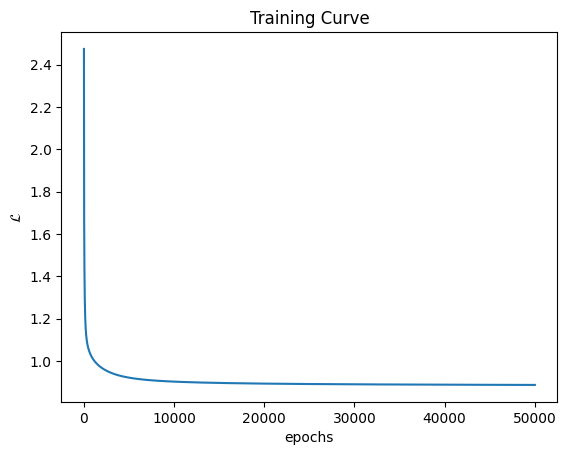

np.float64(0.6089743589743589)

In [43]:
mv_linreg = MVLogisticRegression()
mv_linreg.fit(X, y,alpha=7e-2, epochs=5e4)
y_hat = mv_linreg.predict(X)
accuracy(y,y_hat)

# lin_reg.fit(X[0:1,:],y[0:1])
# y_hat = lin_reg.predict(X[0:1,:])
# accuracy(y[0:1],y_hat)
# y.shape

In [32]:
from sklearn.metrics import confusion_matrix

In [44]:
confusion_matrix(y,y_hat)

array([[ 5,  4,  7,  0],
       [ 2, 23, 34,  8],
       [ 2, 12, 80, 26],
       [ 0,  5, 22, 82]])

In [48]:
class GaussNB():

    def fit(self, X, y, epsilon=1e-3):
        self.likelihoods = dict()
        self.priors = dict()
        self.K = set(y.astype(int))

        for k in self.K:
            X_k = X[y==k]
            self.likelihoods[k] = {'mean':X_k.mean(axis=0), 'cov':X_k.var(axis=0)+epsilon}
            self.priors[k] = len(X_k)/len(X)
    
    def predict(self, X):
        N, d = X.shape
        P_hat = np.zeros((N, len(self.K)))

        for k,l in self.likelihoods.items():
            P_hat[:,k] = mvn.logpdf(X, l['mean'], l['cov']) + np.log(self.priors[k])
        
        return P_hat.argmax(axis=1)
    

In [51]:
gnb = GaussNB()
gnb.fit(X,y)
y_hat_gnb = gnb.predict(X)
accuracy(y, y_hat_gnb)

np.float64(0.38461538461538464)

In [52]:
class GaussBayes():

    def fit(self, X, y, epsilon=1e-3):
        self.params = {}
        self.priors = {}

        self.K = set(y.astype(int))
        
        for k in self.K:
            X_k = X[y==k,:]
            N_k, d = X_k.shape
            mu_k = X_k.mean(axis=0)
            cov_k = (1/(N_k-1)) * np.matmul((X_k-mu_k).T, (X_k-mu_k))+epsilon*np.identity(d)
            self.params[k] = {'mean':mu_k, 'cov':cov_k}
            self.priors[k] = len(X_k)/len(X)

    def predict(self, X):
        N, d = X.shape
        P_hat = np.zeros((N, len(self.K)))

        for k, l in self.params.items():
            P_hat[:,k] = mvn.logpdf(X, l['mean'], l['cov']) + np.log(self.priors[k])

        return P_hat.argmax(axis=1)


In [54]:
gb = GaussBayes()
gb.fit(X,y)
y_hat_gb = gb.predict(X)
accuracy(y, y_hat_gb)

np.float64(0.6378205128205128)

In [106]:
bootstrap_am = int(5e4)
training_percent = .8
N = len(X)
training_am = int(training_percent*N)
indices = np.random.randint(0,training_am ,size=(bootstrap_am))
print(indices.shape)
X_bs = X[indices]
y_bs = y[indices]
X_test = X[training_am+1:]
y_test = y[training_am+1:]

(50000,)


In [107]:
gb_bs = GaussBayes()
gb_bs.fit(X_bs, y_bs)
y_hat_bs = gb_bs.predict(X_bs)
print(accuracy(y_hat_bs, y_bs))
y_test_gb_bs = gb_bs.predict(X_test)
print(accuracy(y_test, y_test_gb_bs))

0.75052
0.3548387096774194


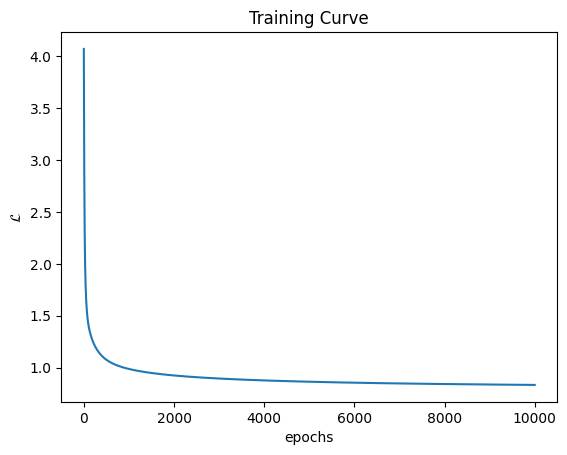

0.6556
0.3870967741935484


In [98]:
mv_logreg_bs = MVLogisticRegression()
mv_logreg_bs.fit(X_bs, y_bs, alpha=5e-2, epochs=1e4)
y_hat_mv_bs = mv_logreg_bs.predict(X_bs)
print(accuracy(y_bs,y_hat_mv_bs))
y_hat_test_mv_bs = mv_logreg_bs.predict(X_test)
print(accuracy(y_test,y_hat_test_mv_bs))

In [81]:
data['stage'].value_counts()

stage
3    120
4    109
2     67
1     16
Name: count, dtype: int64

In [88]:
X_bs_dropped = X_bs[:,[1, 2, 4, 6,7,8,9,10,12,13,15,16,17,18]]
X_bs_dropped.shape

(100000, 14)

In [89]:
gb_bs_dropped = GaussBayes()
gb_bs_dropped.fit(X_bs_dropped, y_bs)
y_hat_bs_dropped = gb_bs_dropped.predict(X_bs_dropped)
print(accuracy(y_hat_bs_dropped, y_bs))
y_test_gb_bs_dropped = gb_bs_dropped.predict(X_test[:,[1, 2, 4, 6,7,8,9,10,12,13,15,16,17,18]])
print(accuracy(y_test, y_test_gb_bs_dropped))

0.59594
0.43548387096774194
